# Spotify Popularity Analysis

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

sns.set_theme()
pd.set_option("display.max_columns", 100)

## 1. Load the dataset

The code below tries a few common file locations so the notebook can still run even if the folder structure changes.

In [2]:
# Load dataset into a pandas DataFrame
df = pd.read_csv("../data/dataset.csv")
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 2. Initial inspection

Before cleaning, inspect the shape, columns, data types, and summary statistics.

In [3]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

display(df.describe(include="all").T.head(25))

Shape: (114000, 21)

Columns:
['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

Data types:


Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,114000.0,NaN,NaN,NaN,56999.5,32909.109681,0.0,28499.75,56999.5,85499.25,113999.0
track_id,114000,89741,6S3JlDAGk3uu3NtZbPnuhS,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
artists,113999,31437,The Beatles,279,NaN,NaN,NaN,NaN,NaN,NaN,NaN
album_name,113999,46589,Alternative Christmas 2022,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
track_name,113999,73608,Run Rudolph Run,151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
popularity,114000.0,NaN,NaN,NaN,33.238535,22.305078,0.0,17.0,35.0,50.0,100.0
duration_ms,114000.0,NaN,NaN,NaN,228029.153114,107297.712645,0.0,174066.0,212906.0,261506.0,5237295.0
explicit,114000,2,False,104253,NaN,NaN,NaN,NaN,NaN,NaN,NaN
danceability,114000.0,NaN,NaN,NaN,0.5668,0.173542,0.0,0.456,0.58,0.695,0.985
energy,114000.0,NaN,NaN,NaN,0.641383,0.251529,0.0,0.472,0.685,0.854,1.0


## 3. Data cleaning

According to the proposal, the dataset should be cleaned by:
- removing the unnecessary index column,
- checking missing values,
- removing duplicates,
- verifying data types.

This helps ensure that the later analysis and models are based on consistent data.

In [4]:
# Remove the unnecessary index column if it exists
# Drop unnecessary columns
df = df.drop(columns=["Unnamed: 0"], errors="ignore")

# Check missing values and duplicates before cleaning
missing_before = df.isnull().sum().sort_values(ascending=False)
# Check for duplicate rows
duplicates_before = df.duplicated().sum()

print("Top missing-value counts before cleaning:")
display(missing_before[missing_before > 0].head(10))
print("Duplicate rows before cleaning:", duplicates_before)

# Drop missing values and duplicates
df = df.dropna().drop_duplicates().reset_index(drop=True)

print("\nShape after cleaning:", df.shape)
# Check for duplicate rows
print("Duplicate rows after cleaning:", df.duplicated().sum())
print("\nData types after cleaning:")
display(df.dtypes)


Top missing-value counts before cleaning:


album_name    1
track_name    1
artists       1
dtype: int64

Duplicate rows before cleaning: 450

Shape after cleaning: (113549, 20)
Duplicate rows after cleaning: 0

Data types after cleaning:


track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

## 4. Basic overview of the target variable

Popularity is the main target in this project. Start by looking at its distribution.

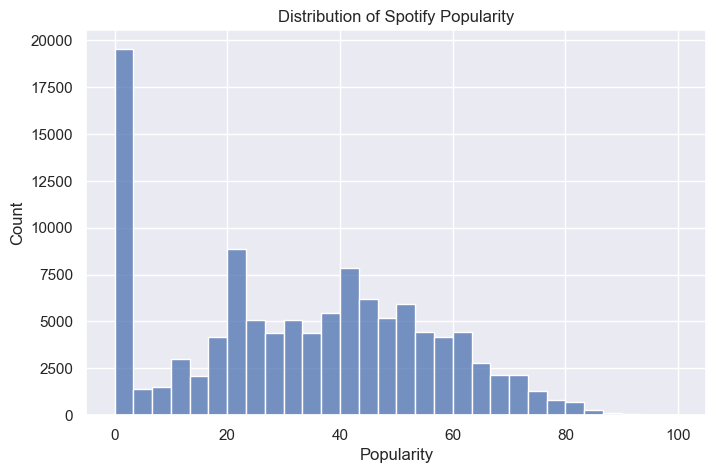

count    113549.000000
mean         33.324433
std          22.283855
min           0.000000
25%          17.000000
50%          35.000000
75%          50.000000
max         100.000000
Name: popularity, dtype: float64


In [5]:
plt.figure(figsize=(8, 5))
# Plot distribution of popularity
sns.histplot(df["popularity"], bins=30)
plt.title("Distribution of Spotify Popularity")
plt.xlabel("Popularity")
plt.ylabel("Count")
plt.show()

print(df["popularity"].describe())


## 5. Quick genre overview

Genre is an important variable in the proposal. A simple first look is to compare the average popularity of the most common genres.

,count,mean
track_genre,,
emo,1000,48.128
mandopop,1000,45.025
electronic,1000,44.325
pagode,1000,44.298
metalcore,1000,43.477
acoustic,1000,42.483
garage,1000,40.933
mpb,1000,40.792
punk-rock,1000,38.236


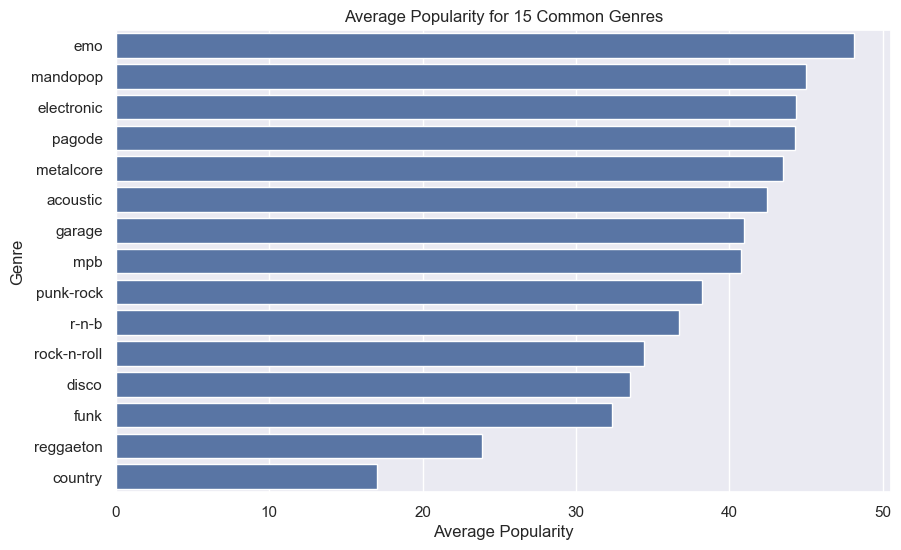

In [6]:
top_genres = df["track_genre"].value_counts().head(15).index
genre_summary = (
    df[df["track_genre"].isin(top_genres)]
    .groupby("track_genre")["popularity"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

display(genre_summary)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=genre_summary.reset_index(),
    x="mean",
    y="track_genre"
)
plt.title("Average Popularity for 15 Common Genres")
plt.xlabel("Average Popularity")
plt.ylabel("Genre")
plt.show()


## 6. Correlation analysis

The proposal emphasizes identifying significant features associated with popularity. A correlation heatmap is a good first step for seeing linear relationships among numeric features.

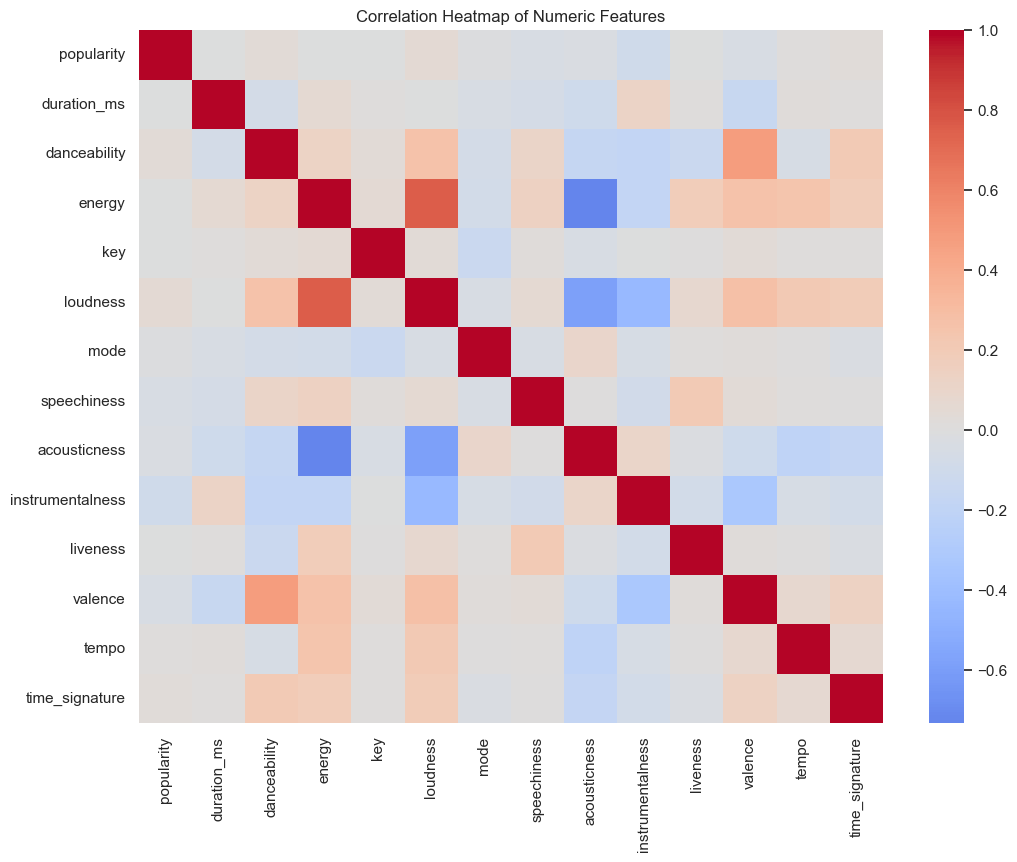

popularity          1.000000
loudness            0.047368
danceability        0.034407
time_signature      0.030567
tempo               0.012187
energy             -0.002447
key                -0.004167
liveness           -0.005668
duration_ms        -0.007928
mode               -0.015009
acousticness       -0.022356
valence            -0.041097
speechiness        -0.045463
instrumentalness   -0.094718
Name: popularity, dtype: float64

In [7]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12, 9))
# Visualize correlations between features
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

corr_with_popularity = numeric_df.corr()["popularity"].sort_values(ascending=False)
display(corr_with_popularity)


## 7. Feature engineering

To match the proposal, create a few simple engineered features:

- `log_duration`: a log transform of song length,
- `energy_loudness`: an interaction feature,
- `popular_song`: a binary label for classification (`popularity >= 70`).

In [9]:
df["log_duration"] = np.log1p(df["duration_ms"])
df["energy_loudness"] = df["energy"] * df["loudness"]
df["popular_song"] = (df["popularity"] >= 70).astype(int)

display(df[["duration_ms", "log_duration", "energy", "loudness", "energy_loudness", "popular_song"]].head())

print("Class balance for popular_song:")
display(df["popular_song"].value_counts(normalize=True).rename("proportion"))


,duration_ms,log_duration,energy,loudness,energy_loudness,popular_song
0,230666,12.348730,0.4610,-6.746,-3.109906,1
1,149610,11.915794,0.1660,-17.235,-2.861010,0
2,210826,12.258793,0.3590,-9.734,-3.494506,0
3,201933,12.215696,0.0596,-18.515,-1.103494,1
4,198853,12.200326,0.4430,-9.681,-4.288683,1


Class balance for popular_song:


popular_song
0    0.951845
1    0.048155
Name: proportion, dtype: float64

## 8. Prepare features for modeling

For the first round of models, use:
- core audio features,
- a few engineered features,
- one-hot encoded genre.

Metadata columns such as track name and artist are excluded because they are not straightforward numerical predictors for these baseline models.

In [10]:
feature_cols = [
    "duration_ms", "explicit", "danceability", "energy", "key", "loudness",
    "mode", "speechiness", "acousticness", "instrumentalness", "liveness",
    "valence", "tempo", "time_signature", "log_duration", "energy_loudness"
]

model_df = df[feature_cols + ["track_genre", "popularity", "popular_song"]].copy()
# Drop unnecessary columns
model_df = pd.get_dummies(model_df, columns=["track_genre"], drop_first=True)

X_reg = model_df.drop(columns=["popularity", "popular_song"])
y_reg = model_df["popularity"]

X_clf = model_df.drop(columns=["popularity", "popular_song"])
y_clf = model_df["popular_song"]

print("Regression feature matrix shape:", X_reg.shape)
print("Classification feature matrix shape:", X_clf.shape)


Regression feature matrix shape: (113549, 129)
Classification feature matrix shape: (113549, 129)


## 9. Regression task: predict popularity

This part matches the proposal's regression goal. Two models are compared:

- Linear Regression as a baseline,
- Random Forest Regressor as a nonlinear model.

In [11]:
# Split data into training and testing sets
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Initialize Linear Regression model
lin_reg = LinearRegression()
# Train the model
lin_reg.fit(X_train_reg, y_train_reg)
# Make predictions
y_pred_lin = lin_reg.predict(X_test_reg)

# Calculate RMSE
lin_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_lin))
# Calculate R-squared
lin_r2 = r2_score(y_test_reg, y_pred_lin)

rf_reg = RandomForestRegressor(
    n_estimators=120,
    max_depth=20,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_reg.fit(X_train_reg, y_train_reg)
# Make predictions
y_pred_rf = rf_reg.predict(X_test_reg)

# Calculate RMSE
rf_rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf))
# Calculate R-squared
rf_r2 = r2_score(y_test_reg, y_pred_rf)

regression_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "RMSE": [lin_rmse, rf_rmse],
    "R2": [lin_r2, rf_r2]
})

display(regression_results)


,Model,RMSE,R2
0,Linear Regression,19.393697,0.250189
1,Random Forest Regressor,20.170291,0.188936


## 10. Regression diagnostics

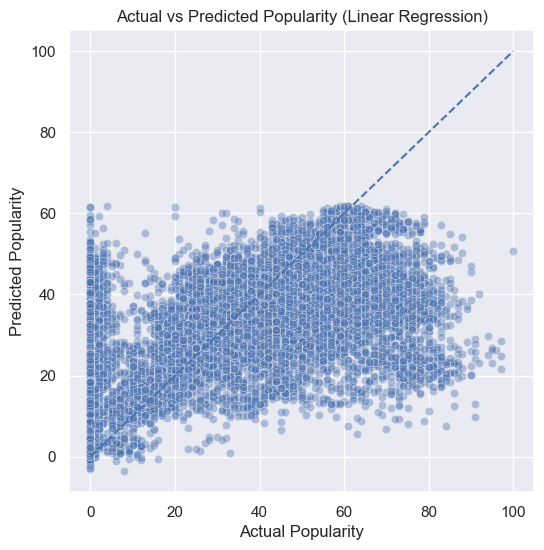

In [12]:
best_reg_name = regression_results.sort_values("RMSE").iloc[0]["Model"]
best_preds = y_pred_rf if best_reg_name == "Random Forest Regressor" else y_pred_lin

plt.figure(figsize=(6, 6))
# Explore relationship with popularity
sns.scatterplot(x=y_test_reg, y=best_preds, alpha=0.4)
plt.plot([0, 100], [0, 100], linestyle="--")
plt.title(f"Actual vs Predicted Popularity ({best_reg_name})")
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.show()


## 11. Feature importance

Use Random Forest feature importance to see which variables contribute most to prediction. 

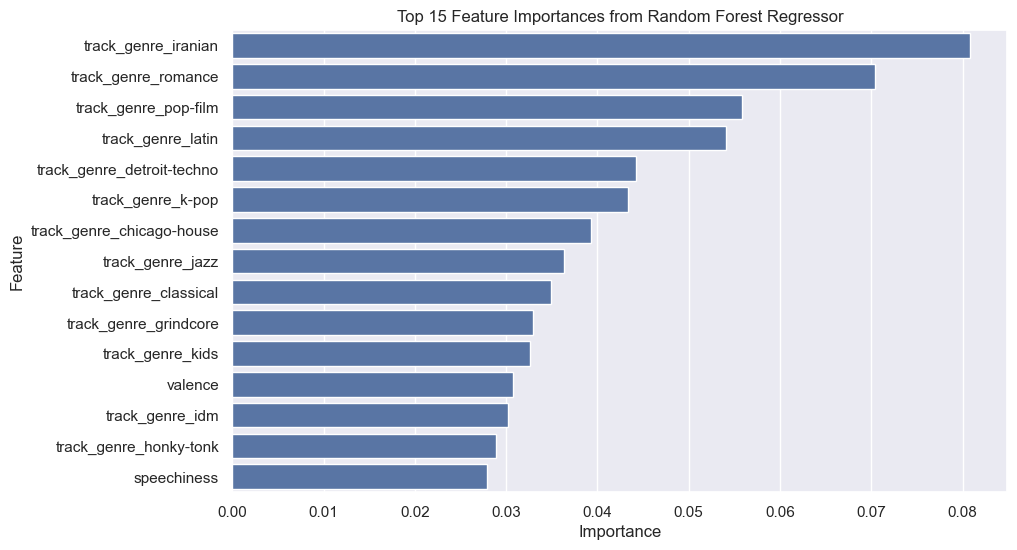

track_genre_iranian           0.080872
track_genre_romance           0.070410
track_genre_pop-film          0.055862
track_genre_latin             0.054102
track_genre_detroit-techno    0.044229
track_genre_k-pop             0.043357
track_genre_chicago-house     0.039306
track_genre_jazz              0.036320
track_genre_classical         0.034923
track_genre_grindcore         0.032983
track_genre_kids              0.032567
valence                       0.030742
track_genre_idm               0.030246
track_genre_honky-tonk        0.028922
speechiness                   0.027919
dtype: float64

In [15]:
rf_importance = pd.Series(rf_reg.feature_importances_, index=X_reg.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=rf_importance.values, y=rf_importance.index)
plt.title("Top 15 Feature Importances from Random Forest Regressor")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

display(rf_importance)
